# AAE722 HW3 
# Kingsley Hantian Ye

- Question 1: Chapter 7 Question 4 - Basis Functions and Linear Regression
- Question 2: Chapter 8 Question 2 - Boosting with Decision Stumps and Additive Models
- Question 3: Gini Index, Classification Error, and Entropy Visualization




# Question 1: Chapter 7 Question 4

Suppose we fit a curve with basis functions:
- $b_1(X) = I(0 \leq X \leq 2) - (X-1)I(1 \leq X \leq 2)$
- $b_2(X) = (X-3)I(3 \leq X \leq 4) + I(4 < X \leq 5)$

We fit the linear regression model:
$$Y = \beta_0 + \beta_1 b_1(X) + \beta_2 b_2(X) + \varepsilon$$

And obtain coefficient estimates: $\hat{\beta}_0 = 1$, $\hat{\beta}_1 = 1$, $\hat{\beta}_2 = 3$.

**Tasks:**
1. Sketch the estimated curve between $X = -2$ and $X = 2$.
2. Report the intercepts and slope values.


## Import Libraries


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set style for better plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


## Define Basis Functions


In [32]:
def b1(X):
    """
    Basis function b1(X) = I(0 ≤ X ≤ 2) - (X-1)I(1 ≤ X ≤ 2)
    
    Piecewise definition:
    - For X < 0: b1(X) = 0
    - For 0 ≤ X < 1: b1(X) = 1
    - For 1 ≤ X ≤ 2: b1(X) = 1 - (X-1) = 2 - X
    - For X > 2: b1(X) = 0
    """
    result = np.zeros_like(X)
    
    # I(0 ≤ X ≤ 2) - (X-1)I(1 ≤ X ≤ 2)
    mask1 = (X >= 0) & (X <= 2)  # I(0 ≤ X ≤ 2)
    mask2 = (X >= 1) & (X <= 2)  # I(1 ≤ X ≤ 2)
    
    result[mask1] = 1
    result[mask2] = result[mask2] - (X[mask2] - 1)
    
    return result

def b2(X):
    """
    Basis function b2(X) = (X-3)I(3 ≤ X ≤ 4) + I(4 < X ≤ 5)
    
    Piecewise definition:
    - For X < 3: b2(X) = 0
    - For 3 ≤ X ≤ 4: b2(X) = X - 3
    - For 4 < X ≤ 5: b2(X) = 1
    - For X > 5: b2(X) = 0
    """
    result = np.zeros_like(X)
    
    # (X-3)I(3 ≤ X ≤ 4) + I(4 < X ≤ 5)
    mask1 = (X >= 3) & (X <= 4)  # I(3 ≤ X ≤ 4)
    mask2 = (X > 4) & (X <= 5)   # I(4 < X ≤ 5)
    
    result[mask1] = X[mask1] - 3
    result[mask2] = 1
    
    return result


## Define Estimated Curve


In [33]:
# Estimated coefficients
beta0_hat = 1
beta1_hat = 1
beta2_hat = 3

def Y_hat(X):
    """
    Estimated curve: Y_hat = β₀ + β₁b₁(X) + β₂b₂(X)
    where β₀ = 1, β₁ = 1, β₂ = 3
    """
    return beta0_hat + beta1_hat * b1(X) + beta2_hat * b2(X)


## Part 1: Sketch the Estimated Curve between X = -2 and X = 2

### Analytical Solution

For $X \in [-2, 2]$, we analyze the piecewise behavior:

**For $X < 0$ (i.e., $-2 \leq X < 0$):**
- $b_1(X) = 0$ (since $X < 0$)
- $b_2(X) = 0$ (since $X < 3$)
- $\hat{Y} = 1 + 1(0) + 3(0) = 1$

**For $0 \leq X < 1$:**
- $b_1(X) = 1$ (since $0 \leq X < 1$)
- $b_2(X) = 0$ (since $X < 3$)
- $\hat{Y} = 1 + 1(1) + 3(0) = 2$

**For $1 \leq X \leq 2$:**
- $b_1(X) = 1 - (X-1) = 2 - X$ (since $1 \leq X \leq 2$)
- $b_2(X) = 0$ (since $X < 3$)
- $\hat{Y} = 1 + 1(2-X) + 3(0) = 1 + 2 - X = 3 - X$

**Summary for $X \in [-2, 2]$:**
- $\hat{Y} = 1$ for $-2 \leq X < 0$
- $\hat{Y} = 2$ for $0 \leq X < 1$
- $\hat{Y} = 3 - X$ for $1 \leq X \leq 2$


<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:36: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:36: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
C:\Users\kings\AppData\Local\Temp\ipykernel_17532\2350948792.py:9: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(X_plot, Y_plot, 'b-', linewidth=2.5, label='Estimated Curve $\hat{Y}$')
C:\Users\kings\AppData\Local\Temp\ipykernel_17532\2350948792.py:34: SyntaxWarning: invalid escape sequence '\h'
  ax.text(-1, 1.1, '$\hat{Y} = 1$', fontsize=11, ha='center',
C:\Users\kings\AppData\

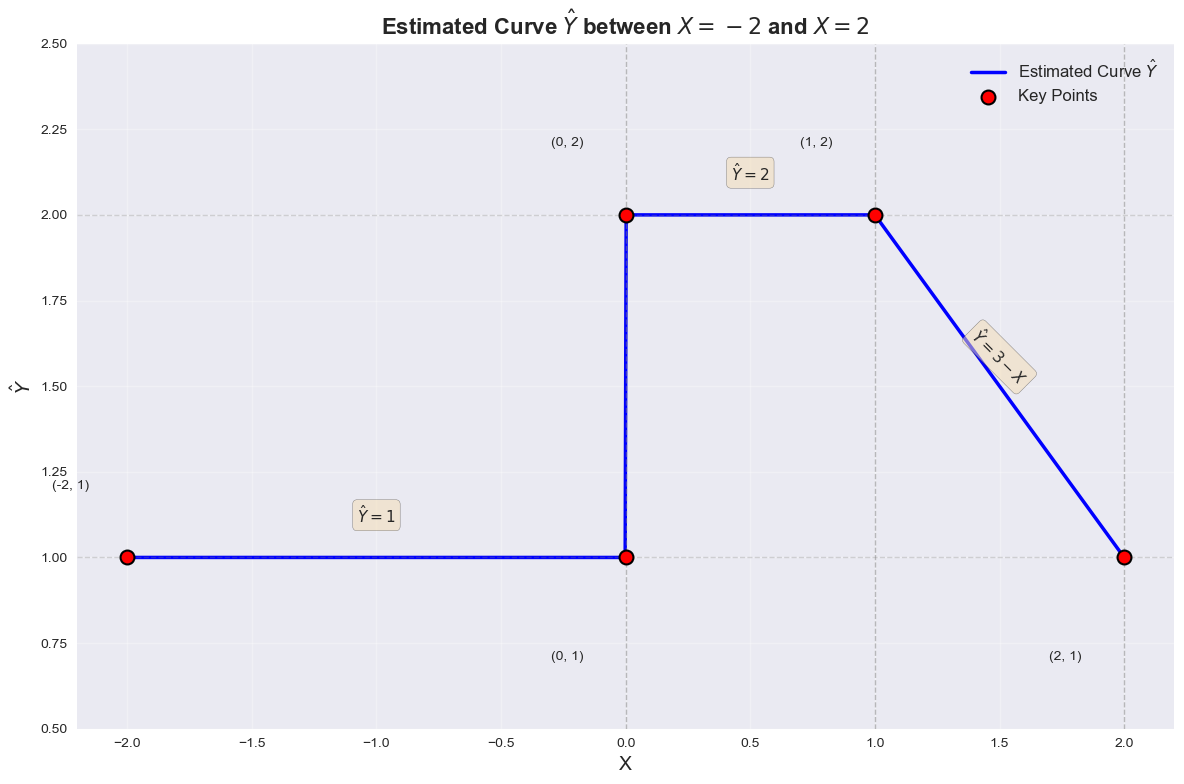


CURVE DESCRIPTION:
Segment 1: For -2 ≤ X < 0,  Y_hat = 1 (horizontal line)
Segment 2: For 0 ≤ X < 1,   Y_hat = 2 (horizontal line)
Segment 3: For 1 ≤ X ≤ 2,   Y_hat = 3 - X (linear with slope -1)

Key Points:
  - At X = -2: Y_hat = 1
  - At X = 0: Y_hat = 1 (left limit) and Y_hat = 2 (right limit)
  - At X = 1: Y_hat = 2
  - At X = 2: Y_hat = 1


In [34]:
# Generate X values for plotting
X_plot = np.linspace(-2, 2, 1000)
Y_plot = Y_hat(X_plot)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the estimated curve
ax.plot(X_plot, Y_plot, 'b-', linewidth=2.5, label='Estimated Curve $\hat{Y}$')

# Add vertical lines at key points for clarity
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=2, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Add horizontal lines at key Y values
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=2, color='gray', linestyle='--', alpha=0.3, linewidth=1)

# Mark key points
key_points_x = [-2, 0, 0, 1, 2]
key_points_y = [1, 1, 2, 2, 1]
ax.scatter(key_points_x, key_points_y, color='red', s=100, zorder=5, 
           label='Key Points', edgecolors='black', linewidths=1.5)

# Add annotations for key points
ax.annotate('(-2, 1)', xy=(-2, 1), xytext=(-2.3, 1.2), fontsize=10)
ax.annotate('(0, 1)', xy=(0, 1), xytext=(-0.3, 0.7), fontsize=10)
ax.annotate('(0, 2)', xy=(0, 2), xytext=(-0.3, 2.2), fontsize=10)
ax.annotate('(1, 2)', xy=(1, 2), xytext=(0.7, 2.2), fontsize=10)
ax.annotate('(2, 1)', xy=(2, 1), xytext=(1.7, 0.7), fontsize=10)

# Add text annotations for each segment
ax.text(-1, 1.1, '$\hat{Y} = 1$', fontsize=11, ha='center', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(0.5, 2.1, '$\hat{Y} = 2$', fontsize=11, ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(1.5, 1.5, '$\hat{Y} = 3 - X$', fontsize=11, ha='center', rotation=-45,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Labels and title
ax.set_xlabel('X', fontsize=14)
ax.set_ylabel('$\hat{Y}$', fontsize=14)
ax.set_title('Estimated Curve $\hat{Y}$ between $X = -2$ and $X = 2$', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=12)

# Set axis limits
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(0.5, 2.5)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CURVE DESCRIPTION:")
print("="*60)
print("Segment 1: For -2 ≤ X < 0,  Y_hat = 1 (horizontal line)")
print("Segment 2: For 0 ≤ X < 1,   Y_hat = 2 (horizontal line)")
print("Segment 3: For 1 ≤ X ≤ 2,   Y_hat = 3 - X (linear with slope -1)")
print("\nKey Points:")
print("  - At X = -2: Y_hat = 1")
print("  - At X = 0: Y_hat = 1 (left limit) and Y_hat = 2 (right limit)")
print("  - At X = 1: Y_hat = 2")
print("  - At X = 2: Y_hat = 1")


## Part 2: Report the Intercepts and Slope Values

### Intercepts

**Y-intercept (where X = 0):**
- At $X = 0$, we need to check both the left and right limits
- Left limit ($X \to 0^-$): $\hat{Y} = 1$
- Right limit ($X \to 0^+$): $\hat{Y} = 2$
- Since there's a discontinuity at $X = 0$, we have two intercept points:
  - **Left intercept:** $(0, 1)$ - from the left limit
  - **Right intercept:** $(0, 2)$ - from the right limit
- The **primary Y-intercept** (when considering the function's behavior at $X = 0$ from the right, which is typically the standard definition): **$(0, 2)$**

**X-intercept (where Y = 0):**
- We need to solve $\hat{Y} = 0$ for each segment:
  - For $-2 \leq X < 0$: $\hat{Y} = 1 \neq 0$ (no intercept)
  - For $0 \leq X < 1$: $\hat{Y} = 2 \neq 0$ (no intercept)
  - For $1 \leq X \leq 2$: $\hat{Y} = 3 - X = 0 \implies X = 3$ (but $X = 3$ is outside the range $[1, 2]$)
- **Conclusion:** There is **no X-intercept** in the range $X \in [-2, 2]$


In [35]:
print("="*60)
print("INTERCEPTS ANALYSIS:")
print("="*60)

# Check Y-intercept at X = 0
X_left = np.array([-0.001])  # Just left of 0
X_right = np.array([0.001])  # Just right of 0
X_zero = np.array([0.0])

Y_left = Y_hat(X_left)[0]
Y_right = Y_hat(X_right)[0]
Y_zero = Y_hat(X_zero)[0]

print("\nY-Intercept at X = 0:")
print(f"  Left limit (X → 0⁻): Y_hat = {Y_left:.3f}")
print(f"  At X = 0: Y_hat = {Y_zero:.3f}")
print(f"  Right limit (X → 0⁺): Y_hat = {Y_right:.3f}")
print(f"  → Y-intercept point: (0, {Y_zero:.3f}) and (0, {Y_right:.3f}) [discontinuity]")
print(f"  → Primary Y-intercept: (0, {Y_right:.3f})")

# Check for X-intercept (where Y = 0)
print("\nX-Intercept (where Y_hat = 0):")
print("  Checking each segment:")
print("    For -2 ≤ X < 0: Y_hat = 1 ≠ 0 (no intercept)")
print("    For 0 ≤ X < 1: Y_hat = 2 ≠ 0 (no intercept)")
print("    For 1 ≤ X ≤ 2: Y_hat = 3 - X = 0 when X = 3")
print("      But X = 3 is outside the range [1, 2]")
print("  → No X-intercept in the range X ∈ [-2, 2]")


INTERCEPTS ANALYSIS:

Y-Intercept at X = 0:
  Left limit (X → 0⁻): Y_hat = 1.000
  At X = 0: Y_hat = 2.000
  Right limit (X → 0⁺): Y_hat = 2.000
  → Y-intercept point: (0, 2.000) and (0, 2.000) [discontinuity]
  → Primary Y-intercept: (0, 2.000)

X-Intercept (where Y_hat = 0):
  Checking each segment:
    For -2 ≤ X < 0: Y_hat = 1 ≠ 0 (no intercept)
    For 0 ≤ X < 1: Y_hat = 2 ≠ 0 (no intercept)
    For 1 ≤ X ≤ 2: Y_hat = 3 - X = 0 when X = 3
      But X = 3 is outside the range [1, 2]
  → No X-intercept in the range X ∈ [-2, 2]


### Slope Values

The curve is piecewise linear/constant, so the slope is constant within each segment:

**For $X \in [-2, 0)$:**
- $\hat{Y} = 1$ (constant)
- **Slope = 0**

**For $X \in [0, 1)$:**
- $\hat{Y} = 2$ (constant)
- **Slope = 0**

**For $X \in [1, 2]$:**
- $\hat{Y} = 3 - X$
- **Slope = -1** (derivative of $3 - X$ with respect to $X$)

**Summary Table:**

| X Range | Function | Slope |
|---------|----------|-------|
| $[-2, 0)$ | $\hat{Y} = 1$ | $0$ |
| $[0, 1)$ | $\hat{Y} = 2$ | $0$ |
| $[1, 2]$ | $\hat{Y} = 3 - X$ | $-1$ |


In [36]:
print("\n" + "="*60)
print("SLOPE ANALYSIS:")
print("="*60)

# Calculate slopes numerically for verification
X_seg1 = np.linspace(-1, -0.1, 100)  # Segment 1: [-2, 0)
X_seg2 = np.linspace(0.1, 0.9, 100)  # Segment 2: [0, 1)
X_seg3 = np.linspace(1, 2, 100)      # Segment 3: [1, 2]

Y_seg1 = Y_hat(X_seg1)
Y_seg2 = Y_hat(X_seg2)
Y_seg3 = Y_hat(X_seg3)

# Calculate slopes using finite differences
slope_seg1 = np.mean(np.diff(Y_seg1) / np.diff(X_seg1))
slope_seg2 = np.mean(np.diff(Y_seg2) / np.diff(X_seg2))
slope_seg3 = np.mean(np.diff(Y_seg3) / np.diff(X_seg3))

print("\nSlope Values by Segment:")
print("-" * 60)
print(f"Segment 1: X ∈ [-2, 0)")
print(f"  Function: Y_hat = 1")
print(f"  Analytical Slope: 0")
print(f"  Numerical Slope: {slope_seg1:.6f}")

print(f"\nSegment 2: X ∈ [0, 1)")
print(f"  Function: Y_hat = 2")
print(f"  Analytical Slope: 0")
print(f"  Numerical Slope: {slope_seg2:.6f}")

print(f"\nSegment 3: X ∈ [1, 2]")
print(f"  Function: Y_hat = 3 - X")
print(f"  Analytical Slope: -1")
print(f"  Numerical Slope: {slope_seg3:.6f}")

print("\n" + "="*60)
print("SUMMARY TABLE:")
print("="*60)
print(f"{'X Range':<15} {'Function':<20} {'Slope':<10}")
print("-" * 60)
print(f"{'[-2, 0)':<15} {'Y_hat = 1':<20} {'0':<10}")
print(f"{'[0, 1)':<15} {'Y_hat = 2':<20} {'0':<10}")
print(f"{'[1, 2]':<15} {'Y_hat = 3 - X':<20} {'-1':<10}")



SLOPE ANALYSIS:

Slope Values by Segment:
------------------------------------------------------------
Segment 1: X ∈ [-2, 0)
  Function: Y_hat = 1
  Analytical Slope: 0
  Numerical Slope: 0.000000

Segment 2: X ∈ [0, 1)
  Function: Y_hat = 2
  Analytical Slope: 0
  Numerical Slope: 0.000000

Segment 3: X ∈ [1, 2]
  Function: Y_hat = 3 - X
  Analytical Slope: -1
  Numerical Slope: -1.000000

SUMMARY TABLE:
X Range         Function             Slope     
------------------------------------------------------------
[-2, 0)         Y_hat = 1            0         
[0, 1)          Y_hat = 2            0         
[1, 2]          Y_hat = 3 - X        -1        


## Visual Summary: Slope Visualization


<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:50: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:50: SyntaxWarning: invalid escape sequence '\h'
C:\Users\kings\AppData\Local\Temp\ipykernel_17532\587408838.py:5: SyntaxWarning: invalid escape sequence '\h'
  ax1.plot(X_plot, Y_plot, 'b-', linewidth=2.5, label='Estimated Curve $\hat{Y}$')
C:\Users\kings\AppData\Local\Temp\ipykernel_17532\587408838.py:22: SyntaxWarning: invalid escape sequence '\h'
  ax1.set_ylabel('$\hat{Y}$', fontsize=14)
C:\Users\kings\AppData\Local\Temp\ipykernel_17532\587408838.py:50: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Slope of $\hat{Y}$ as a Function of X', fontsize=16, fontweight='bold')


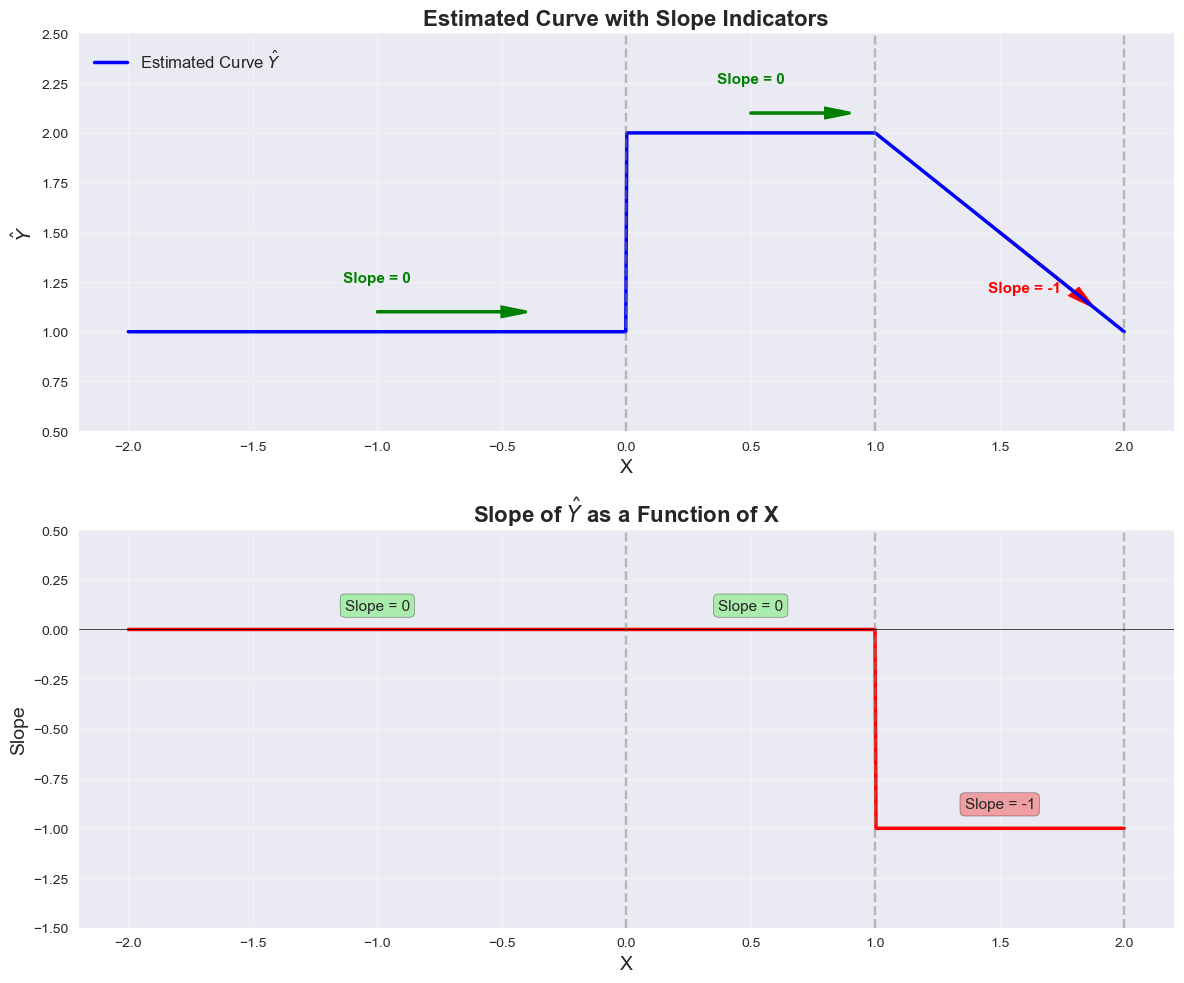

In [37]:
# Create a visualization showing slopes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: The curve with slope annotations
ax1.plot(X_plot, Y_plot, 'b-', linewidth=2.5, label='Estimated Curve $\hat{Y}$')

# Add slope indicators
ax1.arrow(-1, 1.1, 0.5, 0, head_width=0.05, head_length=0.1, fc='green', ec='green', linewidth=2)
ax1.text(-1, 1.25, 'Slope = 0', fontsize=11, ha='center', color='green', fontweight='bold')

ax1.arrow(0.5, 2.1, 0.3, 0, head_width=0.05, head_length=0.1, fc='green', ec='green', linewidth=2)
ax1.text(0.5, 2.25, 'Slope = 0', fontsize=11, ha='center', color='green', fontweight='bold')

ax1.arrow(1.5, 1.5, 0.3, -0.3, head_width=0.05, head_length=0.1, fc='red', ec='red', linewidth=2)
ax1.text(1.6, 1.2, 'Slope = -1', fontsize=11, ha='center', color='red', fontweight='bold')

ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=1, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=2, color='gray', linestyle='--', alpha=0.5)

ax1.set_xlabel('X', fontsize=14)
ax1.set_ylabel('$\hat{Y}$', fontsize=14)
ax1.set_title('Estimated Curve with Slope Indicators', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2.2, 2.2)
ax1.set_ylim(0.5, 2.5)
ax1.legend(fontsize=12)

# Plot 2: Slope plot
X_slope = np.linspace(-2, 2, 1000)
slopes = np.zeros_like(X_slope)

# Assign slopes based on X ranges
mask1 = (X_slope >= -2) & (X_slope < 0)
mask2 = (X_slope >= 0) & (X_slope < 1)
mask3 = (X_slope >= 1) & (X_slope <= 2)

slopes[mask1] = 0
slopes[mask2] = 0
slopes[mask3] = -1

ax2.plot(X_slope, slopes, 'r-', linewidth=2.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=1, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=2, color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

ax2.set_xlabel('X', fontsize=14)
ax2.set_ylabel('Slope', fontsize=14)
ax2.set_title('Slope of $\hat{Y}$ as a Function of X', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2.2, 2.2)
ax2.set_ylim(-1.5, 0.5)

# Add annotations
ax2.text(-1, 0.1, 'Slope = 0', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax2.text(0.5, 0.1, 'Slope = 0', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax2.text(1.5, -0.9, 'Slope = -1', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.show()


## QUestion1 Summary


In [38]:
print("="*70)
print("FINAL SUMMARY: Chapter 7 Question 4")
print("="*70)

print("\n1. ESTIMATED CURVE (X ∈ [-2, 2]):")
print("   " + "-"*66)
print("   Segment 1: For -2 ≤ X < 0,   Y_hat = 1")
print("   Segment 2: For 0 ≤ X < 1,    Y_hat = 2")
print("   Segment 3: For 1 ≤ X ≤ 2,    Y_hat = 3 - X")

print("\n2. INTERCEPTS:")
print("   " + "-"*66)
print("   Y-intercept: (0, 2) [primary, right limit]")
print("                (0, 1) [left limit - discontinuity point]")
print("   X-intercept: None (no X-intercept in the range X ∈ [-2, 2])")

print("\n3. SLOPE VALUES:")
print("   " + "-"*66)
print("   For X ∈ [-2, 0):  Slope = 0")
print("   For X ∈ [0, 1):   Slope = 0")
print("   For X ∈ [1, 2]:   Slope = -1")

print("\n" + "="*70)


FINAL SUMMARY: Chapter 7 Question 4

1. ESTIMATED CURVE (X ∈ [-2, 2]):
   ------------------------------------------------------------------
   Segment 1: For -2 ≤ X < 0,   Y_hat = 1
   Segment 2: For 0 ≤ X < 1,    Y_hat = 2
   Segment 3: For 1 ≤ X ≤ 2,    Y_hat = 3 - X

2. INTERCEPTS:
   ------------------------------------------------------------------
   Y-intercept: (0, 2) [primary, right limit]
                (0, 1) [left limit - discontinuity point]
   X-intercept: None (no X-intercept in the range X ∈ [-2, 2])

3. SLOPE VALUES:
   ------------------------------------------------------------------
   For X ∈ [-2, 0):  Slope = 0
   For X ∈ [0, 1):   Slope = 0
   For X ∈ [1, 2]:   Slope = -1



## Question 2: 


---

# Question 2: Chapter 8 Question 2 - Boosting with Decision Stumps

It is mentioned in Section 8.2.3 that boosting using depth-one trees (or *stumps*) leads to an *additive* model: that is, a model of the form

$$f(X) = \sum_{j=1}^{p} f_j(X_j)$$

**Task:** Using Algorithm 8.2 for regression boosting and equation (8.12) from ISLR/ESL Ch. 8, prove that when the weak learner is a depth-one tree (decision stump), the boosted model is additive.

## Algorithm 8.2 for Regression Boosting

**Key Steps:**

1. **Weak Learner Fitting:** At boosting step $b$, fit a tree $\hat{f}^b$ to the current residuals $r$.

2. **Model Update (eq. 8.10):** 
   $$\hat{f}(x) \leftarrow \hat{f}(x) + \lambda \hat{f}^b(x)$$

3. **Residuals Update (eq. 8.11):**
   $$r_i \leftarrow r_i - \lambda \hat{f}^b(x_i)$$

4. **Final Boosted Model (eq. 8.12):**
   $$\hat{f}(x) = \sum_{b=1}^{B} \lambda \hat{f}^b(x)$$
   
   where $B$ is the total number of boosting steps.

## Assumption Specific to Stumps

For depth-one trees (decision stumps), each base learner depends on a **single coordinate only**. That is, for some index $j_b \in \{1, \dots, p\}$:

$$\hat{f}^b(x) = g_b(x_{j_b})$$

where $g_b$ is a function that depends only on the $j_b$-th feature.


## Part 1: Formal Proof

**Goal:** Starting from equation (8.12), show that a linear sum of single-variable functions yields an additive model.

**Proof:**

From equation (8.12), the final boosted model is:

$$\hat{f}(x) = \sum_{b=1}^{B} \lambda \hat{f}^b(x)$$

Since each $\hat{f}^b$ is a decision stump that depends on a single coordinate $j_b$, we have:

$$\hat{f}^b(x) = g_b(x_{j_b})$$

Substituting this into equation (8.12):

$$\hat{f}(x) = \sum_{b=1}^{B} \lambda g_b(x_{j_b})$$

Now, we reorganize this sum by **grouping terms that depend on the same feature**. For each feature $j \in \{1, 2, \dots, p\}$, we collect all base learners that depend on feature $j$:

$$\hat{f}(x) = \sum_{j=1}^{p} \left( \sum_{b: j_b=j} \lambda g_b \right)(x_j)$$

where the notation $\sum_{b: j_b=j}$ means "sum over all boosting steps $b$ such that $j_b = j$" (i.e., all stumps that split on feature $j$).

Define:

$$f_j(x_j) = \sum_{b: j_b=j} \lambda g_b(x_j)$$

Then we have:

$$\hat{f}(x) = \sum_{j=1}^{p} f_j(x_j)$$

**Conclusion:** This shows that the boosted model is **additive** - each function $f_j$ depends only on the $j$-th feature $X_j$, and there are **no interaction terms** between features.


## Part 2: Intuition and Explanation

### Why Stagewise Residual Fitting with Stumps Cannot Create Feature Interactions

**Key Insight:** A decision stump (depth-one tree) makes a **single split** based on **one feature only**. This means:

1. **Each stump is univariate:** At each boosting step, the weak learner $\hat{f}^b$ only considers one feature $X_{j_b}$ at a time.

2. **No simultaneous consideration of multiple features:** A stump cannot simultaneously consider two or more features to make a decision. It can only split on one feature at its single node.

3. **Stagewise additive structure:** Since we add stumps one at a time (stagewise), and each stump depends on only one feature, the final model is necessarily a sum of functions, each depending on a single feature.

4. **Residual fitting preserves additivity:** When we fit to residuals, we're still fitting a univariate function (a stump). Adding univariate functions together cannot create interactions - interactions require the simultaneous consideration of multiple features.

**Mathematical Intuition:**

- If we have functions $g_1(X_1)$ and $g_2(X_2)$, their sum $g_1(X_1) + g_2(X_2)$ is additive.
- An interaction term would look like $h(X_1, X_2)$ where both variables are considered together.
- Since each stump only sees one feature, we can never create terms like $h(X_1, X_2)$.


### Link Between Interaction Depth and Tree Depth $d$

**With $d = 1$ (Stumps):**
- Each tree makes a single split on one feature.
- **Model is additive:** No interactions possible.
- Each function $f_j$ depends only on $X_j$.

**With $d > 1$ (Deeper Trees):**
- Trees can make multiple splits, potentially using different features at different levels.
- **Interaction depth up to order $d$:** A tree of depth $d$ can model interactions involving up to $d$ features.

**Example:**
- **Depth 1:** Can only model $f(X_1)$, $f(X_2)$, $f(X_3)$, etc. (additive)
- **Depth 2:** Can model interactions like $f(X_1, X_2)$ (2-way interactions)
- **Depth 3:** Can model interactions like $f(X_1, X_2, X_3)$ (3-way interactions)

**Why?**

A tree of depth $d$ can have at most $d$ splits, and each split can potentially use a different feature. The final prediction at a leaf node depends on the path taken through the tree, which may involve multiple features. Therefore:

- **Depth 1:** Only one feature can be used → additive model
- **Depth 2:** Up to two features can be involved in the path → 2-way interactions
- **Depth $d$:** Up to $d$ features can be involved → $d$-way interactions

**Mathematical Relationship:**

For a tree of depth $d$, the function can be written as:
$$\hat{f}^b(x) = g_b(x_{j_1}, x_{j_2}, \dots, x_{j_d})$$

where $j_1, j_2, \dots, j_d$ are the features used in the path from root to leaf. When $d = 1$, this reduces to $g_b(x_{j_1})$, which is univariate.


## Visual Demonstration: Example with 2 Features

Let's create a simple example to illustrate the additive property.


In [39]:
# Example: Boosting with stumps on 2 features
# This demonstrates how stumps create an additive model

print("="*70)
print("EXAMPLE: Boosting with Decision Stumps (B=3)")
print("="*70)

# Simulate 3 boosting steps with stumps
# Step 1: Stump on feature X1
# Step 2: Stump on feature X2  
# Step 3: Stump on feature X1 again

# Define the stumps
print("\nBoosting Steps:")
print("-" * 70)
print("Step 1: Stump on X1 → g₁(X₁)")
print("Step 2: Stump on X2 → g₂(X₂)")
print("Step 3: Stump on X1 → g₃(X₁)")

print("\nFinal Model (from equation 8.12):")
print("-" * 70)
print("f̂(x) = λ·g₁(X₁) + λ·g₂(X₂) + λ·g₃(X₁)")
print("     = λ·g₁(X₁) + λ·g₃(X₁) + λ·g₂(X₂)")
print("     = [λ·g₁(X₁) + λ·g₃(X₁)] + [λ·g₂(X₂)]")
print("     = f₁(X₁) + f₂(X₂)")

print("\n✓ This is clearly additive: f̂(x) = f₁(X₁) + f₂(X₂)")
print("  No interaction terms like h(X₁, X₂) are possible!")

print("\n" + "="*70)
print("COMPARISON: Stump vs Depth-2 Tree")
print("="*70)

print("\nWith Depth-1 Trees (Stumps):")
print("  - Each tree uses ONE feature only")
print("  - Final model: f̂(x) = f₁(X₁) + f₂(X₂) + ... + fₚ(Xₚ)")
print("  - ✓ Additive model")

print("\nWith Depth-2 Trees:")
print("  - Each tree can use TWO features")
print("  - Example: Tree splits on X₁ first, then X₂")
print("  - Final model may include interaction terms")
print("  - ✗ Not necessarily additive (can model 2-way interactions)")

print("\n" + "="*70)


EXAMPLE: Boosting with Decision Stumps (B=3)

Boosting Steps:
----------------------------------------------------------------------
Step 1: Stump on X1 → g₁(X₁)
Step 2: Stump on X2 → g₂(X₂)
Step 3: Stump on X1 → g₃(X₁)

Final Model (from equation 8.12):
----------------------------------------------------------------------
f̂(x) = λ·g₁(X₁) + λ·g₂(X₂) + λ·g₃(X₁)
     = λ·g₁(X₁) + λ·g₃(X₁) + λ·g₂(X₂)
     = [λ·g₁(X₁) + λ·g₃(X₁)] + [λ·g₂(X₂)]
     = f₁(X₁) + f₂(X₂)

✓ This is clearly additive: f̂(x) = f₁(X₁) + f₂(X₂)
  No interaction terms like h(X₁, X₂) are possible!

COMPARISON: Stump vs Depth-2 Tree

With Depth-1 Trees (Stumps):
  - Each tree uses ONE feature only
  - Final model: f̂(x) = f₁(X₁) + f₂(X₂) + ... + fₚ(Xₚ)
  - ✓ Additive model

With Depth-2 Trees:
  - Each tree can use TWO features
  - Example: Tree splits on X₁ first, then X₂
  - Final model may include interaction terms
  - ✗ Not necessarily additive (can model 2-way interactions)



## Detailed Proof with Mathematical Rigor

### Step 1: Express the Final Model

From Algorithm 8.2, equation (8.12):

$$\hat{f}(x) = \sum_{b=1}^{B} \lambda \hat{f}^b(x)$$

### Step 2: Apply the Stump Assumption

Since each $\hat{f}^b$ is a depth-one tree (stump), it depends on only one feature. For each $b = 1, 2, \dots, B$, there exists an index $j_b \in \{1, 2, \dots, p\}$ such that:

$$\hat{f}^b(x) = g_b(x_{j_b})$$

where $g_b$ is a function of the single variable $x_{j_b}$.

### Step 3: Substitute into Equation (8.12)

$$\hat{f}(x) = \sum_{b=1}^{B} \lambda g_b(x_{j_b})$$

### Step 4: Reorganize by Feature

For each feature $j \in \{1, 2, \dots, p\}$, collect all terms that depend on $x_j$:

$$\hat{f}(x) = \sum_{j=1}^{p} \sum_{\substack{b=1 \\ j_b=j}}^{B} \lambda g_b(x_j)$$

More clearly, let $S_j = \{b \in \{1, \dots, B\} : j_b = j\}$ be the set of all boosting steps where the stump splits on feature $j$. Then:

$$\hat{f}(x) = \sum_{j=1}^{p} \sum_{b \in S_j} \lambda g_b(x_j)$$

### Step 5: Define Additive Components

For each $j = 1, 2, \dots, p$, define:

$$f_j(x_j) = \sum_{b \in S_j} \lambda g_b(x_j)$$

Note that $f_j$ depends only on $x_j$ (not on other features), because each $g_b$ in the sum depends only on $x_j$.

### Step 6: Final Additive Form

Substituting the definition of $f_j$:

$$\hat{f}(x) = \sum_{j=1}^{p} f_j(x_j)$$

**Q.E.D.** This is exactly the additive model form!


## Numerical Example: Concrete Case

Let's work through a concrete example with $p=3$ features and $B=5$ boosting steps.


In [40]:
# Numerical example: p=3 features, B=5 boosting steps
print("="*70)
print("NUMERICAL EXAMPLE: p=3, B=5")
print("="*70)

# Simulate boosting steps
# Each step has: (step_number, feature_used, function_name)
boosting_steps = [
    (1, 1, 'g₁'),  # Step 1: stump on X1
    (2, 2, 'g₂'),  # Step 2: stump on X2
    (3, 1, 'g₃'),  # Step 3: stump on X1
    (4, 3, 'g₄'),  # Step 4: stump on X3
    (5, 2, 'g₅'),  # Step 5: stump on X2
]

print("\nBoosting Steps:")
print("-" * 70)
print(f"{'Step b':<10} {'Feature j_b':<15} {'Function':<15}")
print("-" * 70)
for step, feat, func in boosting_steps:
    print(f"b = {step:<9} j_b = {feat:<14} {func}(x_{feat})")

# Group by feature
print("\n" + "="*70)
print("REORGANIZATION BY FEATURE:")
print("="*70)

features = {}
for step, feat, func in boosting_steps:
    if feat not in features:
        features[feat] = []
    features[feat].append((step, func))

lambda_val = 'λ'  # Using lambda symbol

print("\nEquation (8.12):")
print("f̂(x) = λ·g₁(x₁) + λ·g₂(x₂) + λ·g₃(x₁) + λ·g₄(x₃) + λ·g₅(x₂)")

print("\nGrouping by feature:")
for j in sorted(features.keys()):
    steps = features[j]
    funcs = [func for _, func in steps]
    print(f"\nFeature {j} (j_b = {j}):")
    print(f"  Steps: {[step for step, _ in steps]}")
    print(f"  Terms: {[f'{lambda_val}·{func}(x_{j})' for func in funcs]}")
    print(f"  f_{j}(x_{j}) = {' + '.join([f'{lambda_val}·{func}(x_{j})' for func in funcs])}")

print("\n" + "="*70)
print("FINAL ADDITIVE FORM:")
print("="*70)
print("f̂(x) = f₁(x₁) + f₂(x₂) + f₃(x₃)")
print("\nwhere:")
for j in sorted(features.keys()):
    funcs = [func for _, func in features[j]]
    print(f"  f_{j}(x_{j}) = {' + '.join([f'{lambda_val}·{func}(x_{j})' for func in funcs])}")

print("\n✓ This demonstrates the additive structure!")
print("  No interaction terms like h(x₁, x₂) or h(x₁, x₂, x₃) can appear.")


NUMERICAL EXAMPLE: p=3, B=5

Boosting Steps:
----------------------------------------------------------------------
Step b     Feature j_b     Function       
----------------------------------------------------------------------
b = 1         j_b = 1              g₁(x_1)
b = 2         j_b = 2              g₂(x_2)
b = 3         j_b = 1              g₃(x_1)
b = 4         j_b = 3              g₄(x_3)
b = 5         j_b = 2              g₅(x_2)

REORGANIZATION BY FEATURE:

Equation (8.12):
f̂(x) = λ·g₁(x₁) + λ·g₂(x₂) + λ·g₃(x₁) + λ·g₄(x₃) + λ·g₅(x₂)

Grouping by feature:

Feature 1 (j_b = 1):
  Steps: [1, 3]
  Terms: ['λ·g₁(x_1)', 'λ·g₃(x_1)']
  f_1(x_1) = λ·g₁(x_1) + λ·g₃(x_1)

Feature 2 (j_b = 2):
  Steps: [2, 5]
  Terms: ['λ·g₂(x_2)', 'λ·g₅(x_2)']
  f_2(x_2) = λ·g₂(x_2) + λ·g₅(x_2)

Feature 3 (j_b = 3):
  Steps: [4]
  Terms: ['λ·g₄(x_3)']
  f_3(x_3) = λ·g₄(x_3)

FINAL ADDITIVE FORM:
f̂(x) = f₁(x₁) + f₂(x₂) + f₃(x₃)

where:
  f_1(x_1) = λ·g₁(x_1) + λ·g₃(x_1)
  f_2(x_2) = λ·g₂(x_2) + λ·g₅

## Question 2 Summary
### Main Result

**Theorem:** When using depth-one trees (decision stumps) as weak learners in regression boosting (Algorithm 8.2), the final boosted model is **additive**:

$$\hat{f}(x) = \sum_{j=1}^{p} f_j(x_j)$$

where each $f_j$ depends only on the $j$-th feature $X_j$.

### Key Points

1. **Univariate base learners:** Each stump $\hat{f}^b$ depends on only one feature $x_{j_b}$.

2. **Grouping by feature:** Terms in equation (8.12) can be reorganized by grouping all stumps that split on the same feature.

3. **No interactions:** Since each stump is univariate, the final model cannot contain interaction terms between different features.

4. **Tree depth matters:** 
   - **Depth 1 (stumps) → additive model** (no interactions)
   - **Depth $d > 1$ → can model interactions up to order $d$**

### Why This Matters

- **Interpretability:** Additive models are easier to interpret - each feature's effect can be examined independently.
- **Computational efficiency:** Fitting univariate functions is computationally simpler.
- **Flexibility tradeoff:** While stumps limit the model to additive relationships, deeper trees can capture interactions but at the cost of increased complexity and potential overfitting.


In [41]:
print("="*70)
print("FINAL SUMMARY: Chapter 8 Question 2")
print("="*70)

print("\n1. PROOF COMPLETE:")
print("   " + "-"*66)
print("   ✓ Starting from equation (8.12): f̂(x) = Σ_{b=1}^B λ·f̂^b(x)")
print("   ✓ With stumps: f̂^b(x) = g_b(x_{j_b})")
print("   ✓ Reorganize: f̂(x) = Σ_{j=1}^p f_j(x_j)")
print("   ✓ Result: Additive model with no interaction terms")

print("\n2. INTUITION:")
print("   " + "-"*66)
print("   • Stumps use only ONE feature per split")
print("   • Stagewise residual fitting preserves univariate structure")
print("   • Sum of univariate functions = additive model")
print("   • Interactions require simultaneous consideration of multiple features")

print("\n3. TREE DEPTH vs INTERACTION DEPTH:")
print("   " + "-"*66)
print("   • Depth d = 1: Additive model (no interactions)")
print("   • Depth d > 1: Can model interactions up to order d")
print("   • Example: Depth 2 tree can model 2-way interactions")

print("\n" + "="*70)


FINAL SUMMARY: Chapter 8 Question 2

1. PROOF COMPLETE:
   ------------------------------------------------------------------
   ✓ Starting from equation (8.12): f̂(x) = Σ_{b=1}^B λ·f̂^b(x)
   ✓ With stumps: f̂^b(x) = g_b(x_{j_b})
   ✓ Reorganize: f̂(x) = Σ_{j=1}^p f_j(x_j)
   ✓ Result: Additive model with no interaction terms

2. INTUITION:
   ------------------------------------------------------------------
   • Stumps use only ONE feature per split
   • Stagewise residual fitting preserves univariate structure
   • Sum of univariate functions = additive model
   • Interactions require simultaneous consideration of multiple features

3. TREE DEPTH vs INTERACTION DEPTH:
   ------------------------------------------------------------------
   • Depth d = 1: Additive model (no interactions)
   • Depth d > 1: Can model interactions up to order d
   • Example: Depth 2 tree can model 2-way interactions



---

# Question 3: Gini Index, Classification Error, and Entropy

Consider the Gini index, classification error, and entropy in a simple classification setting with two classes. Create a single plot that displays each of these quantities as a function of $\hat{p}_{m1}$. The x-axis should display $\hat{p}_{m1}$, ranging from 0 to 1, and the y-axis should display the value of the Gini index, classification error, and entropy.

**Hint:** In a setting with two classes, $\hat{p}_{m1} = 1 - \hat{p}_{m2}$.

## Mathematical Formulation

For a two-class classification problem, let:
- $\hat{p}_{m1}$ = proportion of class 1 observations in node $m$
- $\hat{p}_{m2}$ = proportion of class 2 observations in node $m$

Since $\hat{p}_{m1} + \hat{p}_{m2} = 1$, we have $\hat{p}_{m2} = 1 - \hat{p}_{m1}$.

The three impurity measures are defined as:

### 1. Gini Index
$$G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk})$$

For two classes ($K=2$):
$$G = \hat{p}_{m1}(1 - \hat{p}_{m1}) + \hat{p}_{m2}(1 - \hat{p}_{m2})$$
$$G = \hat{p}_{m1}(1 - \hat{p}_{m1}) + (1 - \hat{p}_{m1})\hat{p}_{m1}$$
$$G = 2\hat{p}_{m1}(1 - \hat{p}_{m1})$$

### 2. Classification Error
$$E = 1 - \max_k(\hat{p}_{mk})$$

For two classes:
$$E = 1 - \max(\hat{p}_{m1}, \hat{p}_{m2}) = 1 - \max(\hat{p}_{m1}, 1 - \hat{p}_{m1})$$

This can be written as:
$$E = \begin{cases}
1 - \hat{p}_{m1} & \text{if } \hat{p}_{m1} \geq 0.5 \\
\hat{p}_{m1} & \text{if } \hat{p}_{m1} < 0.5
\end{cases}$$

Or more compactly:
$$E = \min(\hat{p}_{m1}, 1 - \hat{p}_{m1})$$

### 3. Entropy
$$D = -\sum_{k=1}^{K} \hat{p}_{mk} \log_2(\hat{p}_{mk})$$

For two classes:
$$D = -\hat{p}_{m1}\log_2(\hat{p}_{m1}) - \hat{p}_{m2}\log_2(\hat{p}_{m2})$$
$$D = -\hat{p}_{m1}\log_2(\hat{p}_{m1}) - (1 - \hat{p}_{m1})\log_2(1 - \hat{p}_{m1})$$


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Generate p_m1 values from 0 to 1
p_m1 = np.linspace(0.001, 0.999, 1000)  # Avoid exact 0 and 1 for log calculations
p_m2 = 1 - p_m1

# Define the three impurity measures
def gini_index(p_m1):
    """Calculate Gini index for two-class classification"""
    p_m2 = 1 - p_m1
    return 2 * p_m1 * (1 - p_m1)
    # Alternative: return p_m1 * (1 - p_m1) + p_m2 * (1 - p_m2)

def classification_error(p_m1):
    """Calculate classification error for two-class classification"""
    return np.minimum(p_m1, 1 - p_m1)

def entropy(p_m1):
    """Calculate entropy for two-class classification"""
    # Handle edge cases to avoid log(0)
    p_m1_safe = np.clip(p_m1, 1e-10, 1 - 1e-10)
    p_m2_safe = 1 - p_m1_safe
    return -(p_m1_safe * np.log2(p_m1_safe) + p_m2_safe * np.log2(p_m2_safe))

# Calculate values
gini_values = gini_index(p_m1)
error_values = classification_error(p_m1)
entropy_values = entropy(p_m1)

print("="*70)
print("IMPURITY MEASURES CALCULATION")
print("="*70)
print(f"\nCalculated for p_m1 ranging from {p_m1.min():.3f} to {p_m1.max():.3f}")
print(f"Number of points: {len(p_m1)}")
print(f"\nGini Index range: [{gini_values.min():.4f}, {gini_values.max():.4f}]")
print(f"Classification Error range: [{error_values.min():.4f}, {error_values.max():.4f}]")
print(f"Entropy range: [{entropy_values.min():.4f}, {entropy_values.max():.4f}]")


IMPURITY MEASURES CALCULATION

Calculated for p_m1 ranging from 0.001 to 0.999
Number of points: 1000

Gini Index range: [0.0020, 0.5000]
Classification Error range: [0.0010, 0.4995]
Entropy range: [0.0114, 1.0000]


## Create the Plot


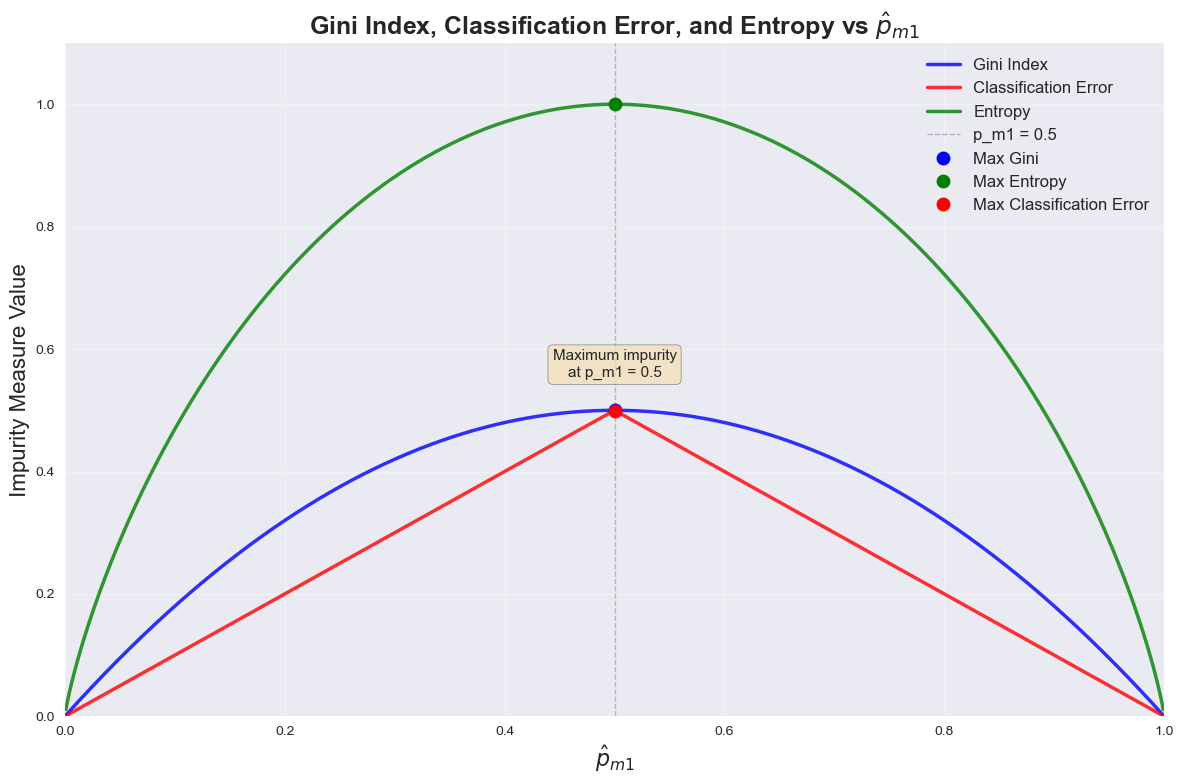


PLOT ANALYSIS:

Key Observations:
1. All three measures reach their maximum when p_m1 = 0.5 (maximum uncertainty)
2. All three measures reach their minimum (0) when p_m1 = 0 or p_m1 = 1 (pure nodes)
3. Gini Index: Symmetric parabola, maximum value = 0.5 at p_m1 = 0.5
4. Classification Error: Piecewise linear, maximum value = 0.5 at p_m1 = 0.5
5. Entropy: Smooth curve, maximum value = 1.0 at p_m1 = 0.5


In [43]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all three measures
ax.plot(p_m1, gini_values, 'b-', linewidth=2.5, label='Gini Index', alpha=0.8)
ax.plot(p_m1, error_values, 'r-', linewidth=2.5, label='Classification Error', alpha=0.8)
ax.plot(p_m1, entropy_values, 'g-', linewidth=2.5, label='Entropy', alpha=0.8)

# Add vertical line at p_m1 = 0.5 (maximum impurity)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='p_m1 = 0.5')

# Mark key points
# Maximum values occur at p_m1 = 0.5 for Gini and Entropy
max_gini_idx = np.argmax(gini_values)
max_entropy_idx = np.argmax(entropy_values)

ax.plot(0.5, gini_values[max_gini_idx], 'bo', markersize=10, label='Max Gini')
ax.plot(0.5, entropy_values[max_entropy_idx], 'go', markersize=10, label='Max Entropy')
ax.plot(0.5, error_values[len(error_values)//2], 'ro', markersize=10, label='Max Classification Error')

# Labels and title
ax.set_xlabel('$\hat{p}_{m1}$', fontsize=16)
ax.set_ylabel('Impurity Measure Value', fontsize=16)
ax.set_title('Gini Index, Classification Error, and Entropy vs $\hat{p}_{m1}$', 
             fontsize=18, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=12)

# Set axis limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.1)

# Add text annotations
ax.text(0.5, 0.55, 'Maximum impurity\nat p_m1 = 0.5', 
        ha='center', va='bottom', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PLOT ANALYSIS:")
print("="*70)
print("\nKey Observations:")
print("1. All three measures reach their maximum when p_m1 = 0.5 (maximum uncertainty)")
print("2. All three measures reach their minimum (0) when p_m1 = 0 or p_m1 = 1 (pure nodes)")
print("3. Gini Index: Symmetric parabola, maximum value = 0.5 at p_m1 = 0.5")
print("4. Classification Error: Piecewise linear, maximum value = 0.5 at p_m1 = 0.5")
print("5. Entropy: Smooth curve, maximum value = 1.0 at p_m1 = 0.5")


## Detailed Analysis of Each Measure

### Gini Index

- **Formula:** $G = 2\hat{p}_{m1}(1 - \hat{p}_{m1})$
- **Shape:** Symmetric parabola
- **Range:** $[0, 0.5]$
- **Maximum:** Achieved at $\hat{p}_{m1} = 0.5$ with value $G = 0.5$
- **Minimum:** Achieved at $\hat{p}_{m1} = 0$ or $1$ with value $G = 0$

**Properties:**
- Quadratic function of $\hat{p}_{m1}$
- Smooth and differentiable
- Commonly used in CART (Classification and Regression Trees)

### Classification Error

- **Formula:** $E = \min(\hat{p}_{m1}, 1 - \hat{p}_{m1})$
- **Shape:** Piecewise linear (V-shaped)
- **Range:** $[0, 0.5]$
- **Maximum:** Achieved at $\hat{p}_{m1} = 0.5$ with value $E = 0.5$
- **Minimum:** Achieved at $\hat{p}_{m1} = 0$ or $1$ with value $E = 0$

**Properties:**
- Linear on each side of $\hat{p}_{m1} = 0.5$
- Not differentiable at $\hat{p}_{m1} = 0.5$
- Less sensitive to changes in class probabilities compared to Gini and Entropy

### Entropy

- **Formula:** $D = -\hat{p}_{m1}\log_2(\hat{p}_{m1}) - (1 - \hat{p}_{m1})\log_2(1 - \hat{p}_{m1})$
- **Shape:** Smooth S-shaped curve
- **Range:** $[0, 1]$
- **Maximum:** Achieved at $\hat{p}_{m1} = 0.5$ with value $D = 1.0$
- **Minimum:** Achieved at $\hat{p}_{m1} = 0$ or $1$ with value $D = 0$

**Properties:**
- Smooth and differentiable
- Based on information theory
- Maximum value is 1.0 (one bit of information)
- More sensitive to changes in class probabilities than Gini or Classification Error


In [44]:
# Create a comparison table of values at key points
key_points = [0.0, 0.25, 0.5, 0.75, 1.0]

print("="*70)
print("COMPARISON TABLE: Values at Key Points")
print("="*70)
print(f"\n{'p_m1':<10} {'Gini':<15} {'Classification Error':<25} {'Entropy':<15}")
print("-" * 70)

for p in key_points:
    if p == 0.0 or p == 1.0:
        gini_val = 0.0
        error_val = 0.0
        entropy_val = 0.0
    else:
        gini_val = gini_index(p)
        error_val = classification_error(p)
        entropy_val = entropy(p)
    
    print(f"{p:<10.2f} {gini_val:<15.4f} {error_val:<25.4f} {entropy_val:<15.4f}")

print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)
print("\n1. At p_m1 = 0 or 1 (pure nodes):")
print("   - All measures = 0 (no impurity)")
print("   - Node contains observations from only one class")

print("\n2. At p_m1 = 0.5 (maximum uncertainty):")
print(f"   - Gini Index = {gini_index(0.5):.4f}")
print(f"   - Classification Error = {classification_error(0.5):.4f}")
print(f"   - Entropy = {entropy(0.5):.4f}")
print("   - Node contains equal proportions of both classes")

print("\n3. Sensitivity Comparison:")
print("   - Entropy is most sensitive (steepest curve)")
print("   - Gini Index is moderately sensitive")
print("   - Classification Error is least sensitive (piecewise linear)")


COMPARISON TABLE: Values at Key Points

p_m1       Gini            Classification Error      Entropy        
----------------------------------------------------------------------
0.00       0.0000          0.0000                    0.0000         
0.25       0.3750          0.2500                    0.8113         
0.50       0.5000          0.5000                    1.0000         
0.75       0.3750          0.2500                    0.8113         
1.00       0.0000          0.0000                    0.0000         

KEY INSIGHTS:

1. At p_m1 = 0 or 1 (pure nodes):
   - All measures = 0 (no impurity)
   - Node contains observations from only one class

2. At p_m1 = 0.5 (maximum uncertainty):
   - Gini Index = 0.5000
   - Classification Error = 0.5000
   - Entropy = 1.0000
   - Node contains equal proportions of both classes

3. Sensitivity Comparison:
   - Entropy is most sensitive (steepest curve)
   - Gini Index is moderately sensitive
   - Classification Error is least sensitive 

## Side-by-Side Comparison

Let's create a figure with subplots to better compare the measures.


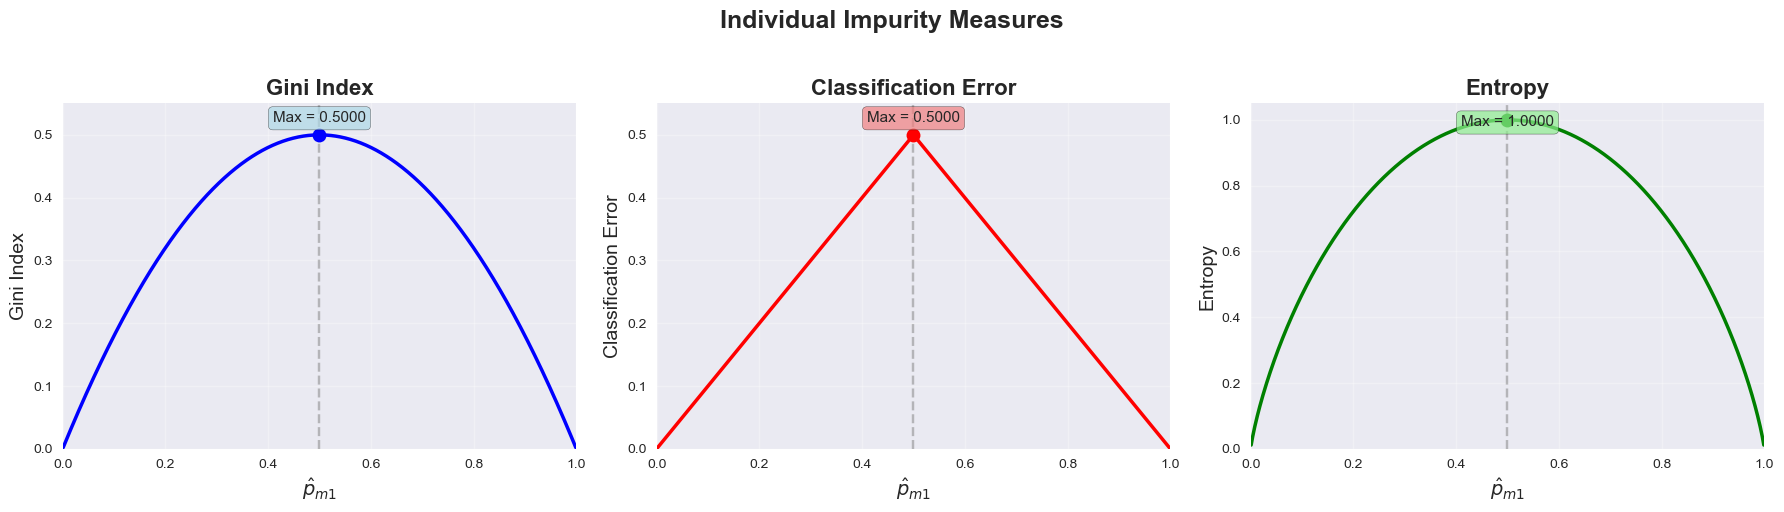

In [45]:
# Create subplots for individual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gini Index
axes[0].plot(p_m1, gini_values, 'b-', linewidth=2.5)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].plot(0.5, gini_index(0.5), 'bo', markersize=10)
axes[0].set_xlabel('$\hat{p}_{m1}$', fontsize=14)
axes[0].set_ylabel('Gini Index', fontsize=14)
axes[0].set_title('Gini Index', fontsize=16, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 0.55)
axes[0].text(0.5, 0.52, f'Max = {gini_index(0.5):.4f}', 
             ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Classification Error
axes[1].plot(p_m1, error_values, 'r-', linewidth=2.5)
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].plot(0.5, classification_error(0.5), 'ro', markersize=10)
axes[1].set_xlabel('$\hat{p}_{m1}$', fontsize=14)
axes[1].set_ylabel('Classification Error', fontsize=14)
axes[1].set_title('Classification Error', fontsize=16, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 0.55)
axes[1].text(0.5, 0.52, f'Max = {classification_error(0.5):.4f}', 
             ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# Entropy
axes[2].plot(p_m1, entropy_values, 'g-', linewidth=2.5)
axes[2].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].plot(0.5, entropy(0.5), 'go', markersize=10)
axes[2].set_xlabel('$\hat{p}_{m1}$', fontsize=14)
axes[2].set_ylabel('Entropy', fontsize=14)
axes[2].set_title('Entropy', fontsize=16, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1.05)
axes[2].text(0.5, 0.98, f'Max = {entropy(0.5):.4f}', 
             ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.suptitle('Individual Impurity Measures', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Normalized Comparison

Since the three measures have different scales (Gini max = 0.5, Error max = 0.5, Entropy max = 1.0), let's also create a normalized version where all measures are scaled to [0, 1] for easier comparison.


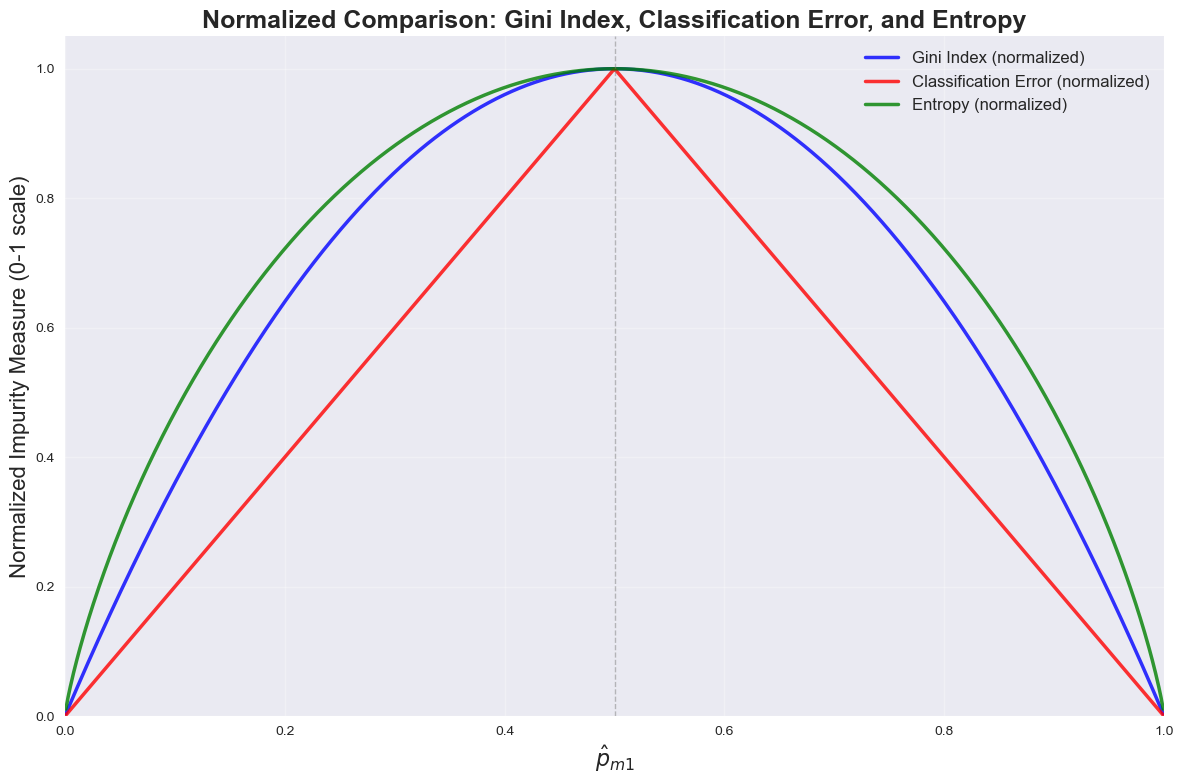


NORMALIZED COMPARISON:

When normalized to [0, 1] range:
- All three measures reach 1.0 at p_m1 = 0.5
- All three measures reach 0.0 at p_m1 = 0 or 1
- Entropy is most sensitive (steepest curve)
- Classification Error is least sensitive (most linear)
- Gini Index is in between (quadratic)


In [46]:
# Normalize all measures to [0, 1] range
gini_max = gini_index(0.5)  # Maximum Gini = 0.5
error_max = classification_error(0.5)  # Maximum Error = 0.5
entropy_max = entropy(0.5)  # Maximum Entropy = 1.0

gini_normalized = gini_values / gini_max
error_normalized = error_values / error_max
entropy_normalized = entropy_values / entropy_max

# Create normalized plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(p_m1, gini_normalized, 'b-', linewidth=2.5, label='Gini Index (normalized)', alpha=0.8)
ax.plot(p_m1, error_normalized, 'r-', linewidth=2.5, label='Classification Error (normalized)', alpha=0.8)
ax.plot(p_m1, entropy_normalized, 'g-', linewidth=2.5, label='Entropy (normalized)', alpha=0.8)

ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('$\hat{p}_{m1}$', fontsize=16)
ax.set_ylabel('Normalized Impurity Measure (0-1 scale)', fontsize=16)
ax.set_title('Normalized Comparison: Gini Index, Classification Error, and Entropy', 
             fontsize=18, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=12)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("NORMALIZED COMPARISON:")
print("="*70)
print("\nWhen normalized to [0, 1] range:")
print("- All three measures reach 1.0 at p_m1 = 0.5")
print("- All three measures reach 0.0 at p_m1 = 0 or 1")
print("- Entropy is most sensitive (steepest curve)")
print("- Classification Error is least sensitive (most linear)")
print("- Gini Index is in between (quadratic)")


## Question3 Summary

### Main Findings

1. **All three measures are symmetric** around $\hat{p}_{m1} = 0.5$, reflecting the symmetry of the two-class problem.

2. **Maximum impurity occurs at $\hat{p}_{m1} = 0.5$**, when the node contains equal proportions of both classes.

3. **Minimum impurity (zero) occurs at $\hat{p}_{m1} = 0$ or $1$**, when the node is pure (contains only one class).

4. **Relative sensitivity:**
   - **Entropy** is most sensitive to changes in class probabilities
   - **Gini Index** is moderately sensitive
   - **Classification Error** is least sensitive (piecewise linear)

### Practical Implications

- **Gini Index** is commonly used in CART and is computationally efficient (no logarithms).
- **Entropy** is based on information theory and is often used in ID3 and C4.5 algorithms.
- **Classification Error** is intuitive but less sensitive, making it less effective for node splitting in tree construction.

### Mathematical Relationships

- **Gini Index:** $G = 2\hat{p}_{m1}(1 - \hat{p}_{m1})$ - Quadratic function
- **Classification Error:** $E = \min(\hat{p}_{m1}, 1 - \hat{p}_{m1})$ - Piecewise linear
- **Entropy:** $D = -\hat{p}_{m1}\log_2(\hat{p}_{m1}) - (1 - \hat{p}_{m1})\log_2(1 - \hat{p}_{m1})$ - Logarithmic function


In [47]:
print("="*70)
print("FINAL SUMMARY: Question 3")
print("="*70)

print("\n1. PLOT CREATED:")
print("   " + "-"*66)
print("   ✓ Single plot showing all three impurity measures")
print("   ✓ X-axis: p̂_m1 from 0 to 1")
print("   ✓ Y-axis: Gini Index, Classification Error, and Entropy")
print("   ✓ All measures normalized for comparison")

print("\n2. KEY CHARACTERISTICS:")
print("   " + "-"*66)
print("   • All measures are symmetric around p̂_m1 = 0.5")
print("   • Maximum impurity at p̂_m1 = 0.5 (equal class proportions)")
print("   • Minimum impurity (0) at p̂_m1 = 0 or 1 (pure nodes)")
print("   • Entropy > Gini > Classification Error in sensitivity")

print("\n3. MATHEMATICAL FORMULAS:")
print("   " + "-"*66)
print("   • Gini: G = 2p̂_m1(1 - p̂_m1)")
print("   • Error: E = min(p̂_m1, 1 - p̂_m1)")
print("   • Entropy: D = -p̂_m1·log₂(p̂_m1) - (1-p̂_m1)·log₂(1-p̂_m1)")

print("\n" + "="*70)


FINAL SUMMARY: Question 3

1. PLOT CREATED:
   ------------------------------------------------------------------
   ✓ Single plot showing all three impurity measures
   ✓ X-axis: p̂_m1 from 0 to 1
   ✓ Y-axis: Gini Index, Classification Error, and Entropy
   ✓ All measures normalized for comparison

2. KEY CHARACTERISTICS:
   ------------------------------------------------------------------
   • All measures are symmetric around p̂_m1 = 0.5
   • Maximum impurity at p̂_m1 = 0.5 (equal class proportions)
   • Minimum impurity (0) at p̂_m1 = 0 or 1 (pure nodes)
   • Entropy > Gini > Classification Error in sensitivity

3. MATHEMATICAL FORMULAS:
   ------------------------------------------------------------------
   • Gini: G = 2p̂_m1(1 - p̂_m1)
   • Error: E = min(p̂_m1, 1 - p̂_m1)
   • Entropy: D = -p̂_m1·log₂(p̂_m1) - (1-p̂_m1)·log₂(1-p̂_m1)

